In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')
%matplotlib inline

import tensorflow as tf
from keras.preprocessing.image import load_img
from keras.models import Sequential, Model
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D, Input

In [2]:
import os
from tqdm import tqdm

# Define BASE_DIR properly
BASE_DIR = "C:/Users/hp/Downloads/archive/utkface_aligned_cropped/UTKFace"  # Update this with the actual directory path

# Lists to store data
image_paths = []
age_labels = []
gender_labels = []

# Loop through files in the directory
for filename in tqdm(os.listdir(BASE_DIR)):
    image_path = os.path.join(BASE_DIR, filename)
    
    # Split filename assuming format: age_gender_something.jpg
    temp = os.path.splitext(filename)[0].split('_')
    
    # Ensure filename has at least two parts (age and gender)
    if len(temp) < 2:
        print(f"Skipping file {filename} due to unexpected format")
        continue  # Skip this file and move to the next one

    try:
        age = int(temp[0])  # Convert age to an integer
        gender = int(temp[1])  # Convert gender to an integer
    except ValueError:
        print(f"Skipping file {filename} due to conversion error")
        continue  # Skip this file and move to the next one

    # Store valid data
    image_paths.append(image_path)
    age_labels.append(age)
    gender_labels.append(gender)

# Print a summary
print(f"Processed {len(image_paths)} images successfully!")


100%|████████████████████████████████████████████████████████████████████████| 23708/23708 [00:00<00:00, 162521.41it/s]

Processed 23708 images successfully!


In [3]:
# labels - age, gender, ethnicity
image_paths = []
age_labels = []
gender_labels = []

for filename in tqdm(os.listdir(BASE_DIR)):
    image_path = os.path.join(BASE_DIR, filename)
    temp = filename.split('_')
    age = int(temp[0])
    gender = int(temp[1])
    image_paths.append(image_path)
    age_labels.append(age)
    gender_labels.append(gender) 

100%|████████████████████████████████████████████████████████████████████████| 23708/23708 [00:00<00:00, 210831.25it/s]


In [4]:
# convert to dataframe
df = pd.DataFrame()
df['image'], df['age'], df['gender'] = image_paths, age_labels, gender_labels
df.head()

,image,age,gender
0,C:/Users/hp/Downloads/archive/utkface_aligned_...,100,0
1,C:/Users/hp/Downloads/archive/utkface_aligned_...,100,0
2,C:/Users/hp/Downloads/archive/utkface_aligned_...,100,1
3,C:/Users/hp/Downloads/archive/utkface_aligned_...,100,1
4,C:/Users/hp/Downloads/archive/utkface_aligned_...,100,1


In [5]:
# map labels for gender
gender_dict = {0:'Male', 1:'Female'}

In [6]:
from PIL import Image
img = Image.open(df['image'][0])
plt.axis('off')
plt.imshow(img);

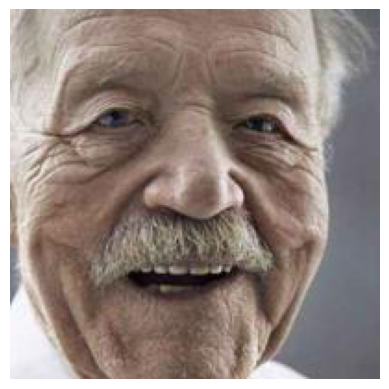

In [7]:
plt.show()

In [8]:
sns.distplot(df['age'])

<Axes: xlabel='age', ylabel='Density'>

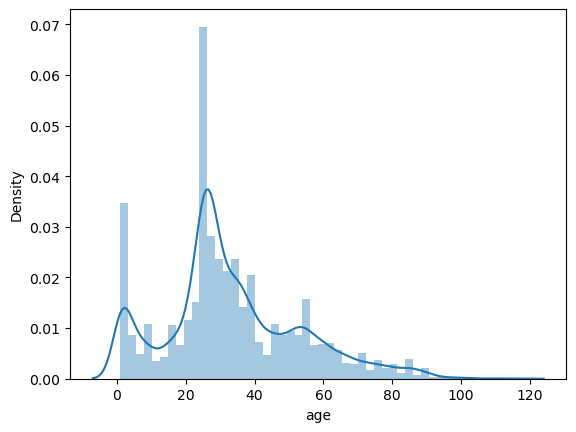

In [9]:
plt.show()

In [10]:
sns.countplot(df['gender'])

<Axes: ylabel='count'>

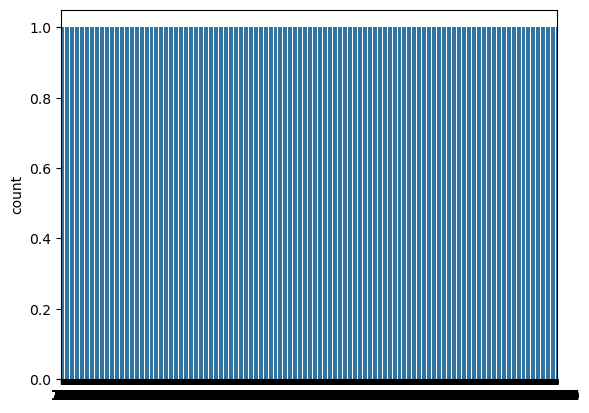

In [11]:
plt.show()

In [12]:
# to display grid of images
plt.figure(figsize=(20, 20))
files = df.iloc[0:25]

for index, file, age, gender in files.itertuples():
    plt.subplot(5, 5, index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title(f"Age: {age} Gender: {gender_dict[gender]}")
    plt.axis('off')

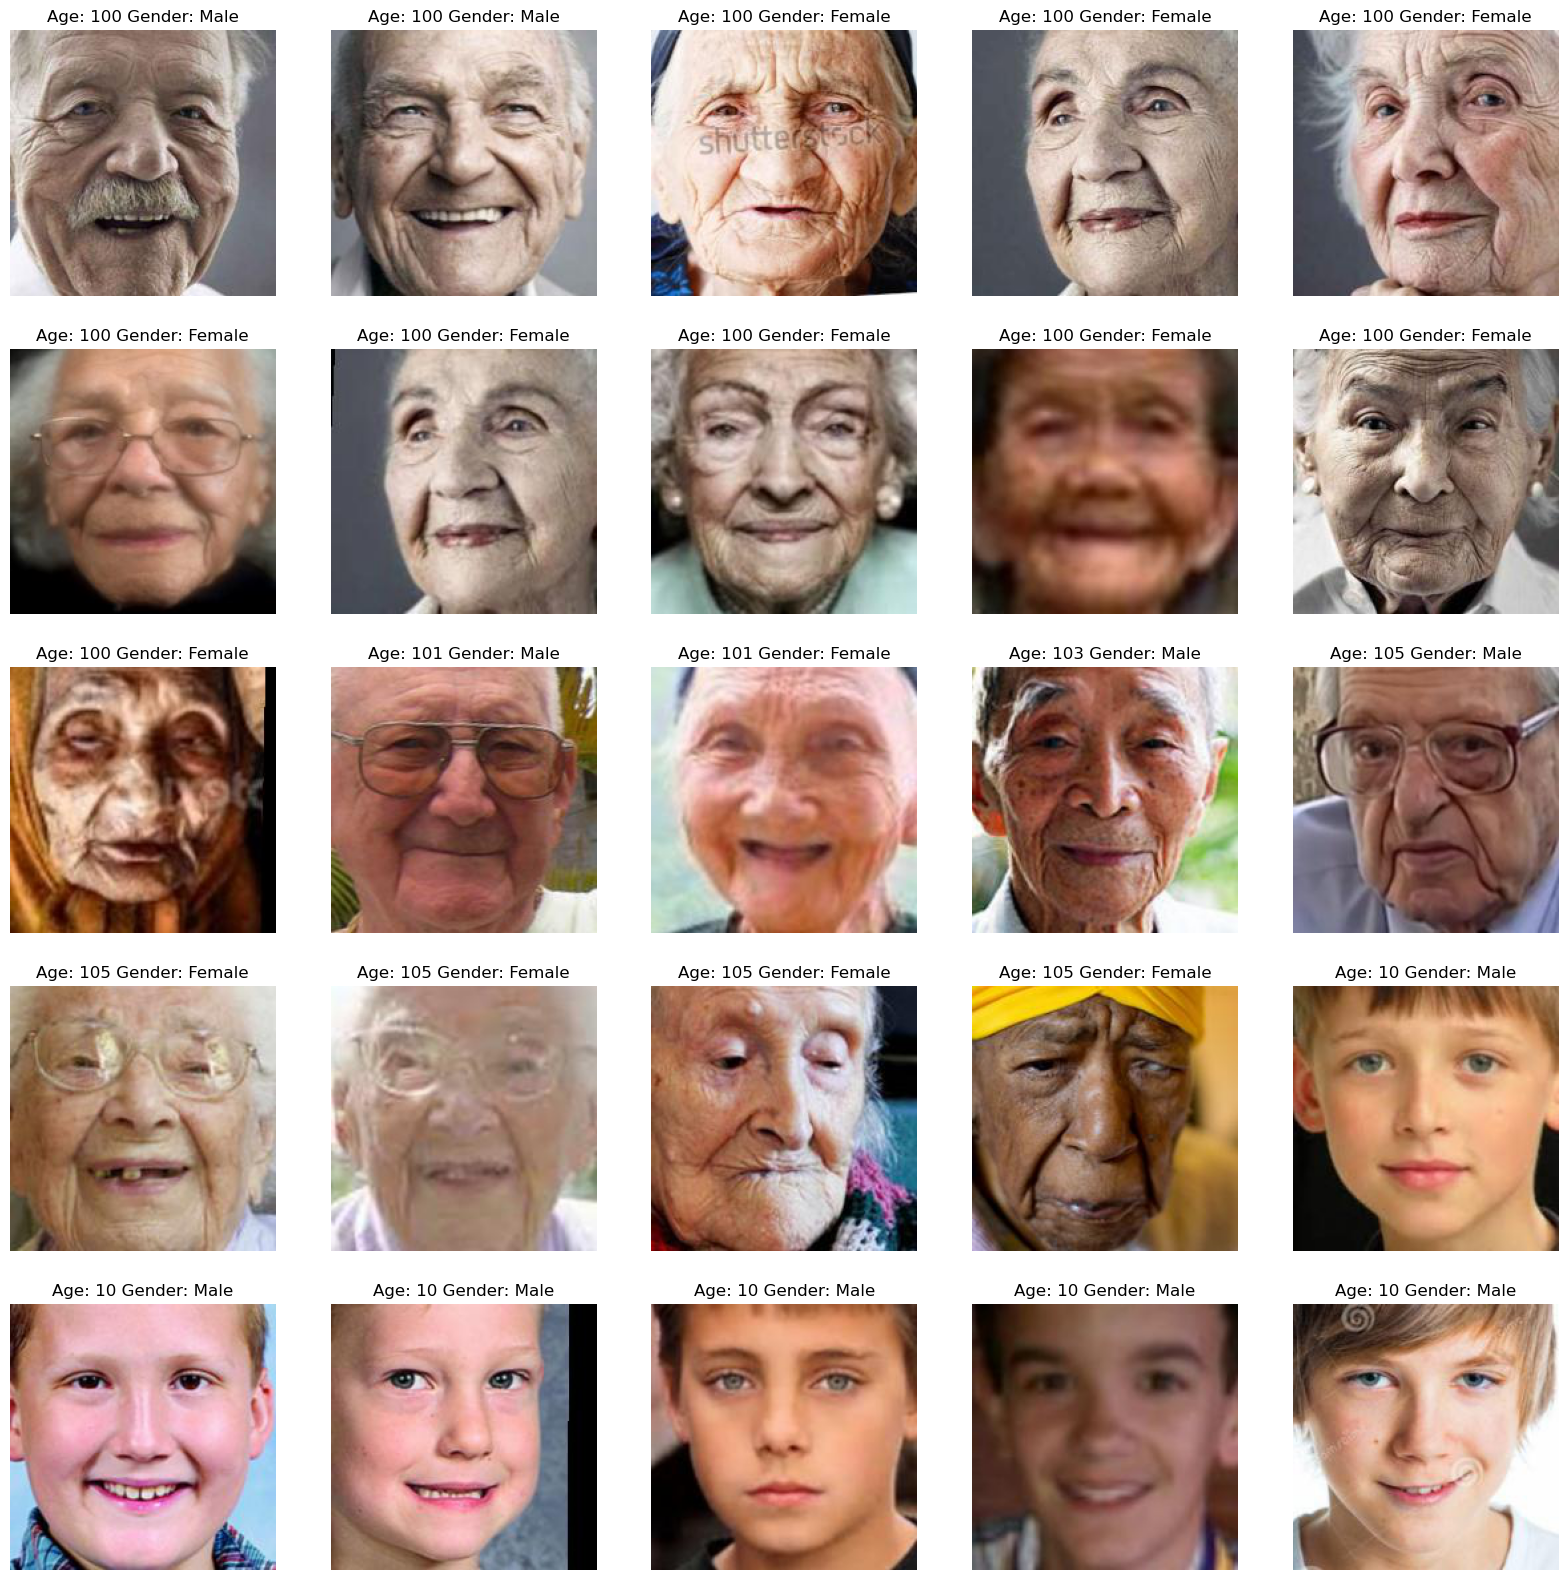

In [13]:
plt.show()

In [14]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode='grayscale')
        img = img.resize((128, 128), Image.ANTIALIAS)
        img = np.array(img)
        features.append(img)
        
    features = np.array(features)
    # ignore this step if using RGB
    features = features.reshape(len(features), 128, 128, 1)
    return features

In [15]:
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import load_img
import numpy as np

def extract_features(images):
    features = []
    for image in tqdm(images):
        img = load_img(image, color_mode='grayscale')
        img = img.resize((128, 128))  # Removed Image.ANTIALIAS
        img = np.array(img)
        features.append(img)
    return np.array(features)

X = extract_features(df['image'])
print(X.shape)


100%|███████████████████████████████████████████████████████████████████████████| 23708/23708 [03:24<00:00, 115.94it/s]


(23708, 128, 128)


In [16]:
# normalize the images
X = X/255.0

In [17]:
y_gender = np.array(df['gender'])
y_age = np.array(df['age'])

In [18]:
input_shape = (128, 128, 1)

In [19]:
inputs = Input((input_shape))
# convolutional layers
conv_1 = Conv2D(32, kernel_size=(3, 3), activation='relu') (inputs)
maxp_1 = MaxPooling2D(pool_size=(2, 2)) (conv_1)
conv_2 = Conv2D(64, kernel_size=(3, 3), activation='relu') (maxp_1)
maxp_2 = MaxPooling2D(pool_size=(2, 2)) (conv_2)
conv_3 = Conv2D(128, kernel_size=(3, 3), activation='relu') (maxp_2)
maxp_3 = MaxPooling2D(pool_size=(2, 2)) (conv_3)
conv_4 = Conv2D(256, kernel_size=(3, 3), activation='relu') (maxp_3)
maxp_4 = MaxPooling2D(pool_size=(2, 2)) (conv_4)

flatten = Flatten() (maxp_4)

# fully connected layers
dense_1 = Dense(256, activation='relu') (flatten)
dense_2 = Dense(256, activation='relu') (flatten)

dropout_1 = Dropout(0.4) (dense_1)
dropout_2 = Dropout(0.4) (dense_2)

output_1 = Dense(1, activation='sigmoid', name='gender_out') (dropout_1)
output_2 = Dense(1, activation='relu', name='age_out') (dropout_2)

model = Model(inputs=[inputs], outputs=[output_1, output_2])

model.compile(loss=['binary_crossentropy', 'mae'], optimizer='adam', metrics=['accuracy', 'mae'])

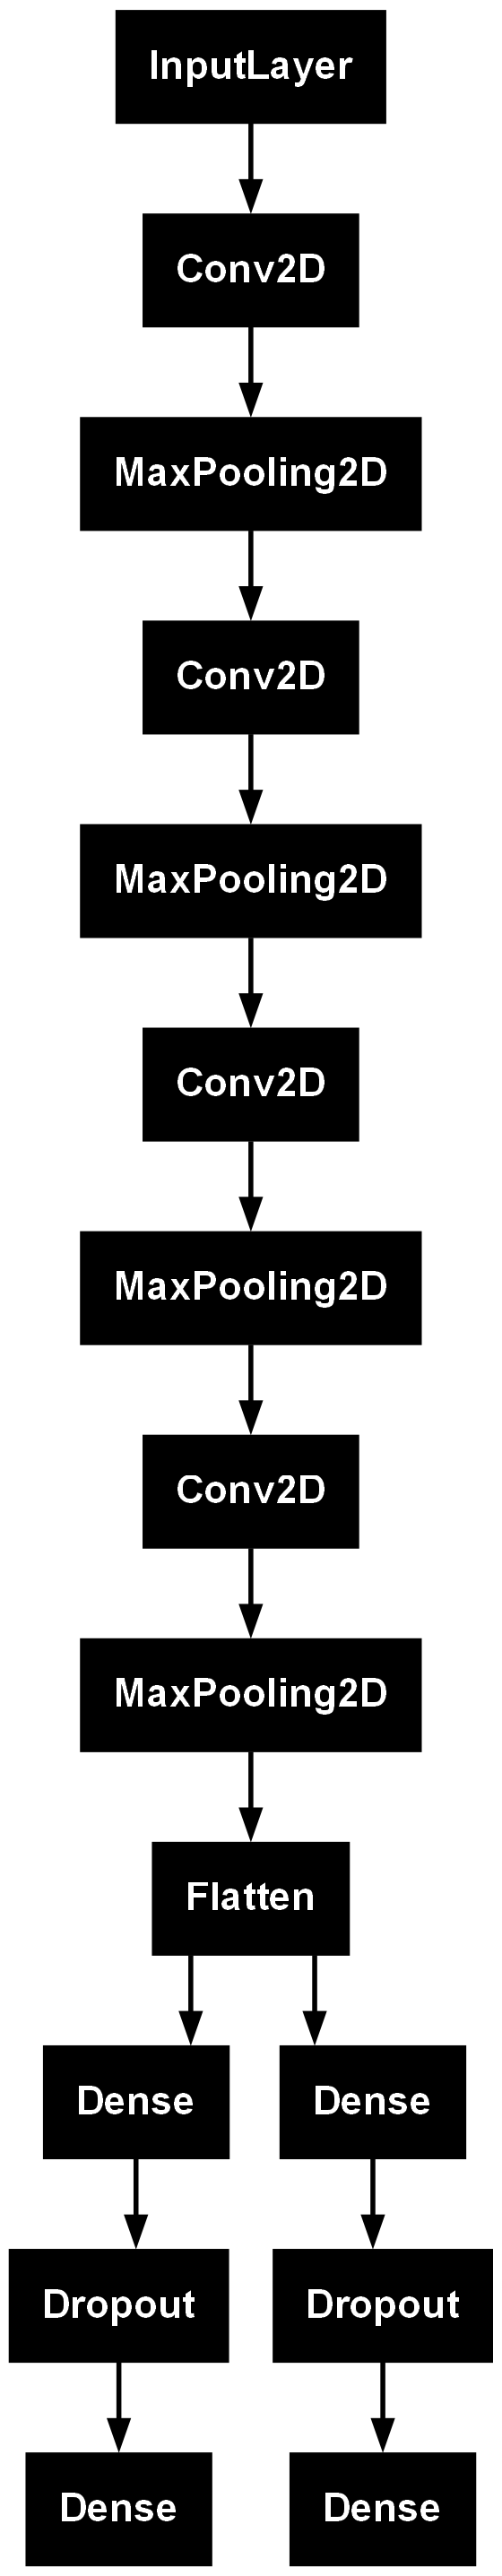

In [20]:
# plot the model
from tensorflow.keras.utils import plot_model
plot_model(model)

In [21]:
pip install pydot

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install pydot graphviz


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [23]:

import pydot
import graphviz
print("pydot and graphviz installed successfully!")



pydot and graphviz installed successfully!


In [25]:

# train model
history = model.fit(x=X, y=[y_gender, y_age], batch_size=32, epochs=30, validation_split=0.2)

Epoch 1/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 178s 291ms/step - age_out_loss: 12.0837 - age_out_mae: 12.0837 - gender_out_accuracy: 0.5060 - gender_out_loss: 0.7273 - loss: 12.8110 - val_age_out_loss: 35.2238 - val_age_out_mae: 35.3334 - val_gender_out_accuracy: 0.5808 - val_gender_out_loss: 0.6810 - val_loss: 36.0141
Epoch 2/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 181s 306ms/step - age_out_loss: 9.3431 - age_out_mae: 9.3431 - gender_out_accuracy: 0.6115 - gender_out_loss: 0.6330 - loss: 9.9761 - val_age_out_loss: 30.4760 - val_age_out_mae: 30.6077 - val_gender_out_accuracy: 0.7474 - val_gender_out_loss: 0.5164 - val_loss: 31.1255
Epoch 3/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 184s 310ms/step - age_out_loss: 7.2612 - age_out_mae: 7.2612 - gender_out_accuracy: 0.7877 - gender_out_loss: 0.4406 - loss: 7.7018 - val_age_out_loss: 29.9327 - val_age_out_mae: 30.0609 - val_gender_out_accuracy: 0.7672 - val_gender_out_loss: 0.4786 - val_loss: 30.5401
Epoch 4/30
593/593 ━━━━━━━━━━━━━━━━━━━━ 184s 311ms/step - age_ou

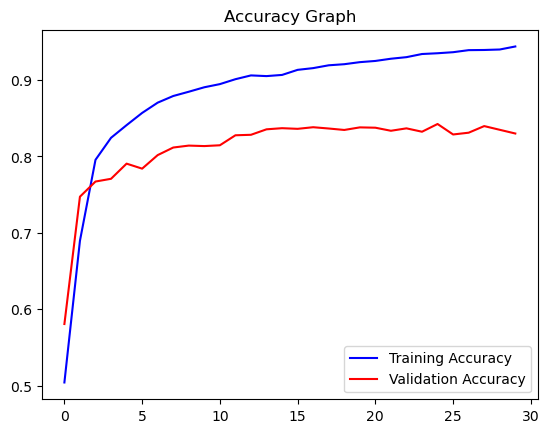

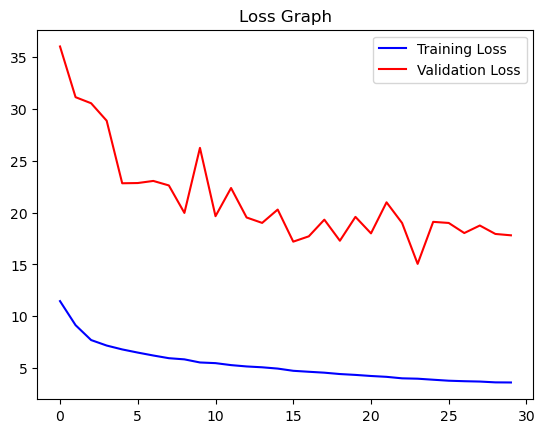

In [26]:
# plot results for gender
acc = history.history['gender_out_accuracy']
val_acc = history.history['val_gender_out_accuracy']
epochs = range(len(acc))

plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.figure()

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss Graph')
plt.legend()
plt.show()


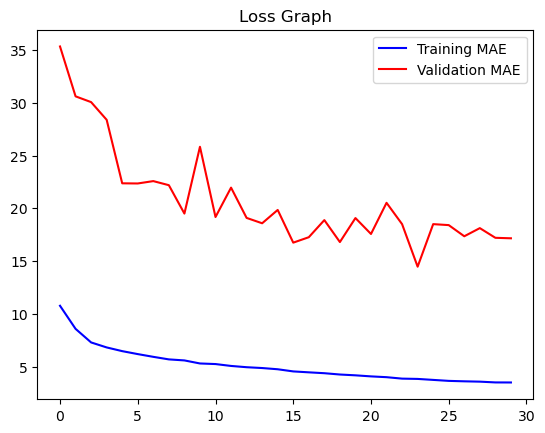

In [27]:
# plot results for age
loss = history.history['age_out_mae']
val_loss = history.history['val_age_out_mae']
epochs = range(len(loss))

plt.plot(epochs, loss, 'b', label='Training MAE')
plt.plot(epochs, val_loss, 'r', label='Validation MAE')
plt.title('Loss Graph')
plt.legend()
plt.show()

Original Gender: Female Original Age: 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted Gender: Female Predicted Age: 10


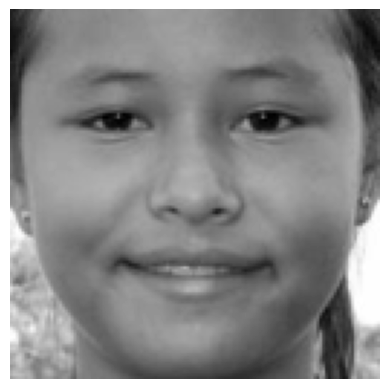

In [37]:
image_index = 150
print("Original Gender:", gender_dict[y_gender[image_index]], "Original Age:", y_age[image_index])
# predict from model
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))
pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])
print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray');
plt.show()

Original Gender: Female Original Age: 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
Predicted Gender: Female Predicted Age: 11


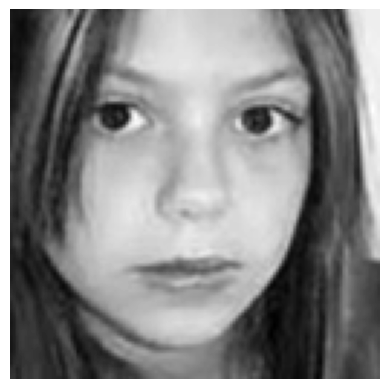

In [38]:

image_index = 170
print("Original Gender:", gender_dict[y_gender[image_index]], "Original Age:", y_age[image_index])
# predict from model
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))
pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])
print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray');
plt.show()

Original Gender: Female Original Age: 11
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted Gender: Female Predicted Age: 12


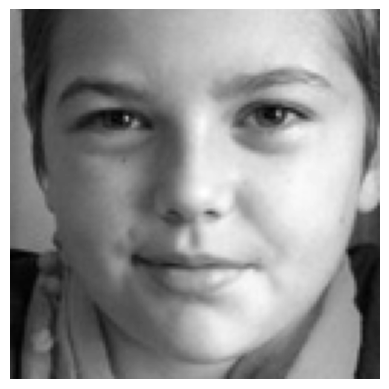

In [36]:

image_index = 240
print("Original Gender:", gender_dict[y_gender[image_index]], "Original Age:", y_age[image_index])
# predict from model
pred = model.predict(X[image_index].reshape(1, 128, 128, 1))
pred_gender = gender_dict[round(pred[0][0][0])]
pred_age = round(pred[1][0][0])
print("Predicted Gender:", pred_gender, "Predicted Age:", pred_age)
plt.axis('off')
plt.imshow(X[image_index].reshape(128, 128), cmap='gray');
plt.show()